# 01 — Exploratory data analysis

Read-only view of the 450 real solder joint samples. No models, no GAN, no scaling.

Two things this notebook establishes:

1. **The layout bug.** The original thesis code reshaped a `(6, 4, 450)` array to `(450, 24)` in C-order, which mixes feature values across samples. This notebook shows the correct layout (per-sample rows) and the buggy layout side by side, on the real data.
2. **The data.** Feature distributions grouped by physical category, target distribution, and feature-target correlations. This is what the GAN and the models notebooks will refer to.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from solder_reliability import find_repo_root
from solder_reliability.data_prep import load_raw
from solder_reliability import viz

# nbconvert and Jupyter run the kernel from the notebook's folder.
# Pin cwd to repo root so data/raw and reports/figures resolve correctly.
os.chdir(find_repo_root(Path.cwd()))

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
RAW_DIR = Path('data/raw')

# Feature names in fixed-layout column order (X[:, i] for i in 0..23).
# Row 1..24 of data/README.md, mapped to the C-order flattening of the
# (6, 4) feature block in each Data_Matrix_*.txt file.
FEATURE_NAMES = [
    'hot_dwell_temp',             # 0
    'solder_density',             # 1
    'upper_layer_density',        # 2
    'lower_layer_density',        # 3
    'hot_dwell_time',             # 4
    'solder_cte',                 # 5
    'upper_layer_cte',            # 6
    'lower_layer_cte',            # 7
    'heating_ramp',               # 8
    'solder_melting_temp',        # 9
    'upper_layer_melting_temp',   # 10
    'lower_layer_melting_temp',   # 11
    'cold_dwell_temp',            # 12
    'solder_youngs_modulus',      # 13
    'upper_layer_youngs_modulus', # 14
    'lower_layer_youngs_modulus', # 15
    'cold_dwell_time',            # 16
    'solder_poisson',             # 17
    'upper_layer_poisson',        # 18
    'lower_layer_poisson',        # 19
    'cooling_ramp',               # 20
    'solder_thickness',           # 21
    'solder_width',               # 22
    'solder_length',              # 23
]
assert len(FEATURE_NAMES) == 24

FEATURE_GROUPS = {
    'thermal':    [0, 4, 8, 12, 16, 20],
    'material':   [1, 2, 3, 5, 6, 7, 9, 10, 11],
    'mechanical': [13, 14, 15, 17, 18, 19],
    'geometric':  [21, 22, 23],
}
GROUP_COLORS = {
    'thermal':    '#d62728',
    'material':   '#1f77b4',
    'mechanical': '#2ca02c',
    'geometric':  '#ff7f0e',
}
FEATURE_GROUP_OF = {i: g for g, idxs in FEATURE_GROUPS.items() for i in idxs}
assert sorted(FEATURE_GROUP_OF) == list(range(24))

for g, idxs in FEATURE_GROUPS.items():
    print(f'{g:10s} {len(idxs)} features')

thermal    6 features
material   9 features
mechanical 6 features
geometric  3 features


## 1. Load both layouts

`load_raw` returns `(X, y)`. The two layouts differ only in how the feature block is unrolled; the target `y` is identical between them.

In [3]:
X_fixed, y_fixed = load_raw(RAW_DIR, layout='fixed')
X_orig,  y_orig  = load_raw(RAW_DIR, layout='original')

print('fixed    X:', X_fixed.shape, X_fixed.dtype, ' y:', y_fixed.shape)
print('original X:', X_orig.shape,  X_orig.dtype,  ' y:', y_orig.shape)
print()
print('y identical across layouts:', bool(np.array_equal(y_fixed, y_orig)))
print('X identical across layouts:', bool(np.allclose(X_fixed, X_orig)))

fixed    X: (450, 24) float64  y: (450,)
original X: (450, 24) float64  y: (450,)

y identical across layouts: True
X identical across layouts: False


## 2. The layout proof

Each `.txt` file holds one sample as a 7x4 matrix. Six of those rows are features, so the file contains 24 feature values. The target sits at `(6, 0)` with NaN padding to `(6, 1:4)`.

`layout="fixed"` unrolls the 6x4 feature block row by row into `X[i]`, so row `i` contains the 24 features of sample `i`.

`layout="original"` reproduces the thesis's C-order reshape of the `(6, 4, 450)` array. That means sample `i` in the resulting `X` is a mix of feature values drawn from many different joints.

Same data, different pairings.

In [4]:
row_fixed = X_fixed[0]
row_orig  = X_orig[0]

print('fixed    X[0, :4] =', row_fixed[:4])
print('original X[0, :4] =', row_orig[:4])
print()
print('fixed X[0] in full:')
for i, (name, v) in enumerate(zip(FEATURE_NAMES, row_fixed)):
    print(f'  {i:2d}  {name:30s}  {v:12.4f}')

assert not np.allclose(row_fixed, row_orig), 'layouts unexpectedly identical'
print()
print('Row 0 differs across layouts, as expected.')

fixed    X[0, :4] = [140.     7.38   2.3    7.76]
original X[0, :4] = [140. 125. 130. 135.]

fixed X[0] in full:
   0  hot_dwell_temp                      140.0000
   1  solder_density                        7.3800
   2  upper_layer_density                   2.3000
   3  lower_layer_density                   7.7600
   4  hot_dwell_time                       13.0000
   5  solder_cte                           21.6000
   6  upper_layer_cte                       3.0000
   7  lower_layer_cte                      24.8000
   8  heating_ramp                        210.0000
   9  solder_melting_temp                 220.0000
  10  upper_layer_melting_temp           1412.0000
  11  lower_layer_melting_temp           1083.0000
  12  cold_dwell_temp                     -10.0000
  13  solder_youngs_modulus                50.0000
  14  upper_layer_youngs_modulus          112.0000
  15  lower_layer_youngs_modulus          110.0000
  16  cold_dwell_time                      11.0000
  17  solder_poisson

## 3. Target distribution

`y` is the FEM-simulated useful lifetime in hours. Note the scale: the target spans a wide range and is right-skewed. The models are trying to explain this from the 24 features.

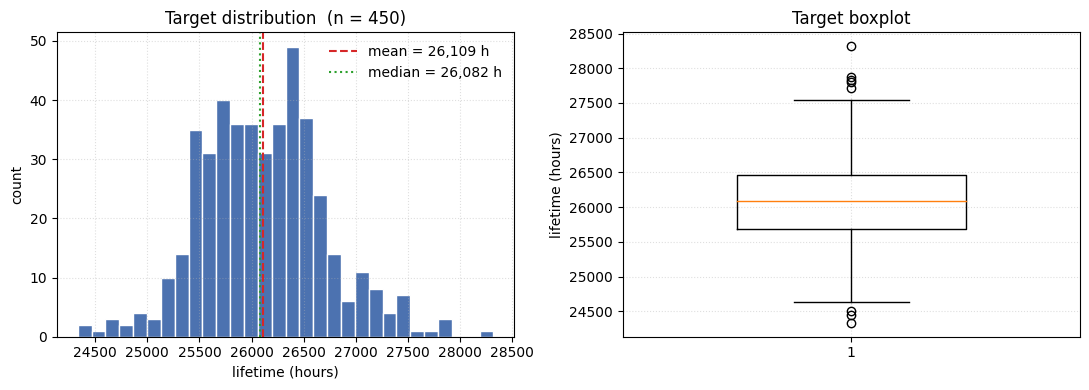

saved reports\figures\eda_target_distribution.png

min        24,332 h
max        28,318 h
mean       26,109 h
median     26,082 h
std           595 h


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(y_fixed, bins=30, color='#4c72b0', edgecolor='white')
ax.axvline(np.mean(y_fixed),   color='#d62728', linestyle='--',
           label=f'mean = {np.mean(y_fixed):,.0f} h')
ax.axvline(np.median(y_fixed), color='#2ca02c', linestyle=':',
           label=f'median = {np.median(y_fixed):,.0f} h')
ax.set_xlabel('lifetime (hours)')
ax.set_ylabel('count')
ax.set_title(f'Target distribution  (n = {len(y_fixed)})')
ax.grid(linestyle=':', alpha=0.4)
ax.legend(frameon=False)

ax = axes[1]
ax.boxplot(y_fixed, vert=True, widths=0.5)
ax.set_ylabel('lifetime (hours)')
ax.set_title('Target boxplot')
ax.grid(linestyle=':', alpha=0.4)

fig.tight_layout()
p = viz.save_figure(fig, 'eda_target_distribution')
plt.show()
print('saved', p)

print()
print(f'min    {y_fixed.min():>10,.0f} h')
print(f'max    {y_fixed.max():>10,.0f} h')
print(f'mean   {y_fixed.mean():>10,.0f} h')
print(f'median {np.median(y_fixed):>10,.0f} h')
print(f'std    {y_fixed.std():>10,.0f} h')

## 4. Feature distributions, grouped by physical category

Six thermal, nine material, six mechanical, three geometric. Colours match the category legend. Look for features with almost no spread, which will not carry signal no matter what model is used.

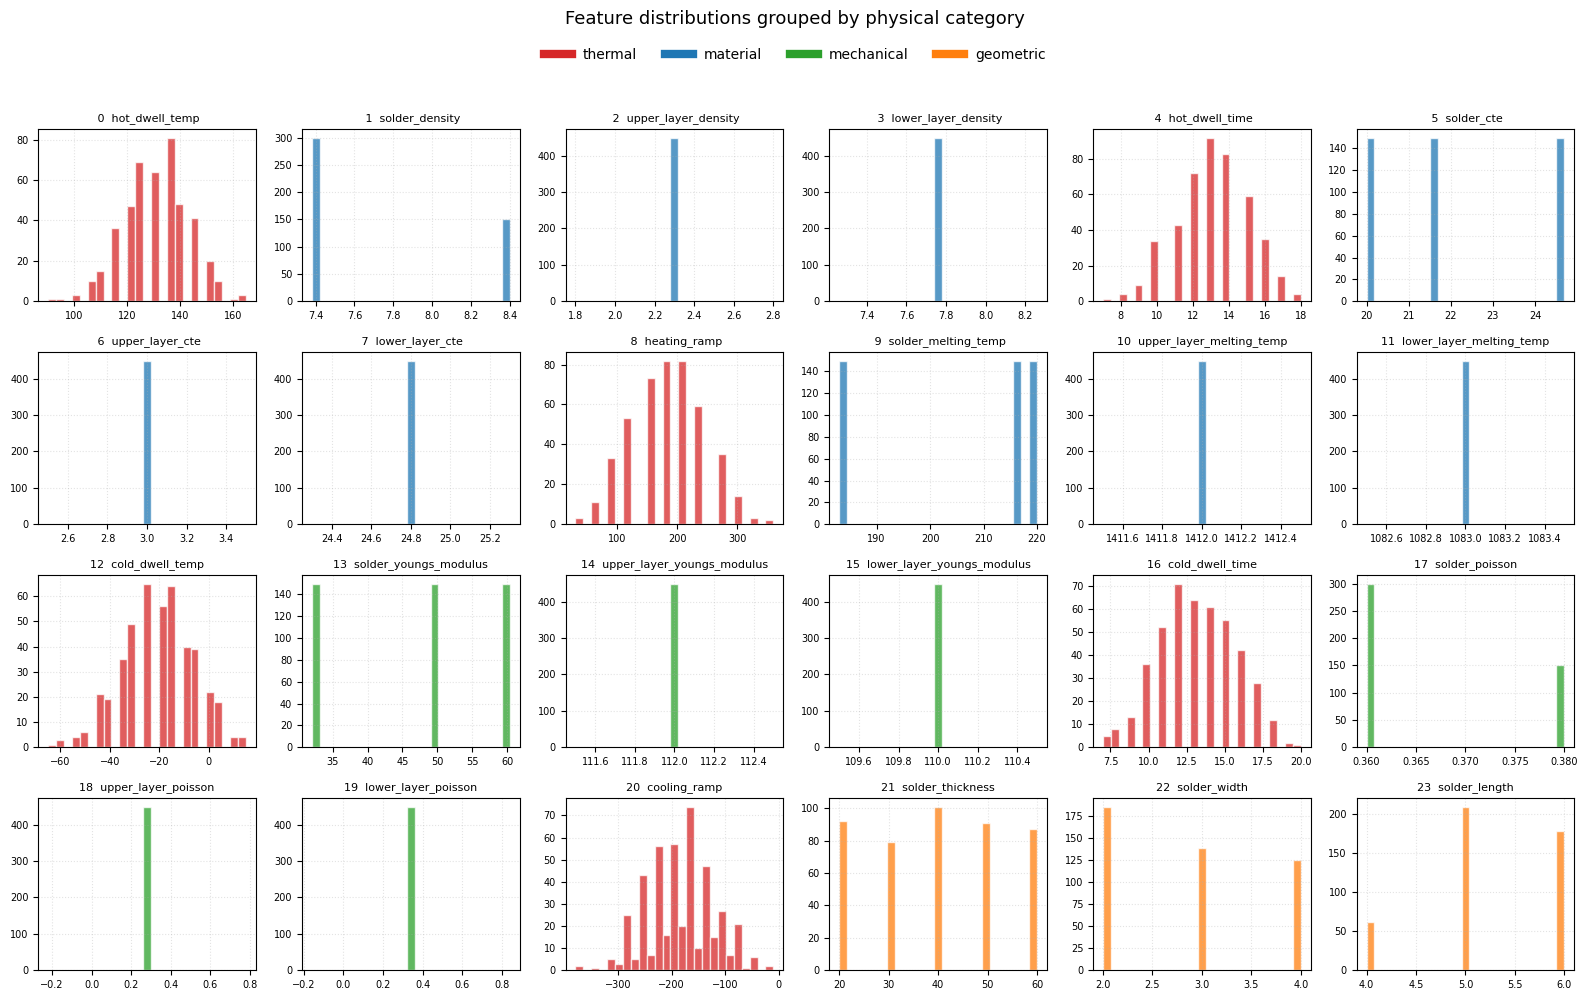

saved reports\figures\eda_feature_distributions.png


In [6]:
fig, axes = plt.subplots(4, 6, figsize=(16, 10))
axes = axes.ravel()

for i, name in enumerate(FEATURE_NAMES):
    ax = axes[i]
    g = FEATURE_GROUP_OF[i]
    ax.hist(X_fixed[:, i], bins=25, color=GROUP_COLORS[g],
            alpha=0.75, edgecolor='white')
    ax.set_title(f'{i:2d}  {name}', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(linestyle=':', alpha=0.35)

for ax in axes[len(FEATURE_NAMES):]:
    ax.axis('off')

handles = [plt.Line2D([0], [0], color=c, lw=6, label=g)
           for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=4,
           frameon=False, bbox_to_anchor=(0.5, 0.97))
fig.suptitle('Feature distributions grouped by physical category',
             fontsize=13, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.94))
p = viz.save_figure(fig, 'eda_feature_distributions')
plt.show()
print('saved', p)

## 5. Feature correlations

Two views. First the full 24x24 correlation matrix, ordered so that features from the same physical category sit next to each other. Second, the correlation of each feature with the target.

C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\numpy\lib\function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


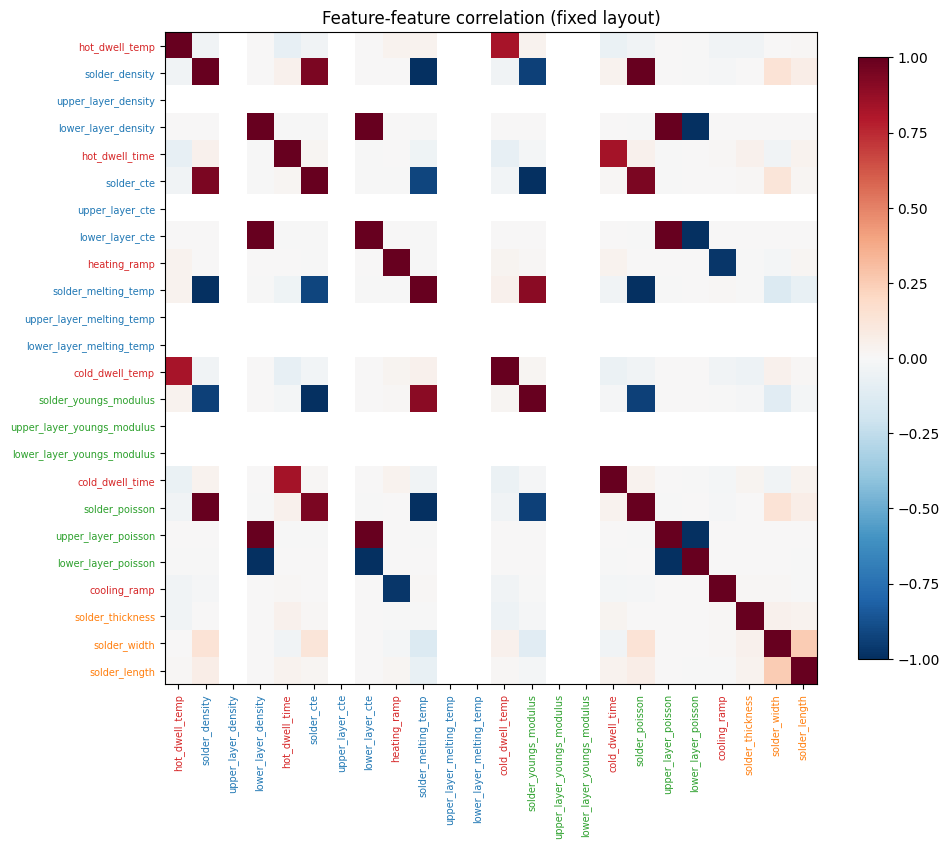

saved reports\figures\eda_correlation.png

Top 10 correlated feature pairs (by |r|):
  +nan  hot_dwell_temp                  upper_layer_density
  -0.086  hot_dwell_temp                  hot_dwell_time
  +nan  hot_dwell_temp                  upper_layer_cte
  +nan  hot_dwell_temp                  upper_layer_melting_temp
  +nan  hot_dwell_temp                  lower_layer_melting_temp
  +nan  hot_dwell_temp                  upper_layer_youngs_modulus
  +nan  hot_dwell_temp                  lower_layer_youngs_modulus
  +nan  solder_density                  upper_layer_density
  +nan  solder_density                  upper_layer_cte
  -0.997  solder_density                  solder_melting_temp


In [7]:
corr = np.corrcoef(X_fixed, rowvar=False)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')

ax.set_xticks(range(24))
ax.set_yticks(range(24))
ax.set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(FEATURE_NAMES, fontsize=7)

for lbl, i in zip(ax.get_xticklabels(), range(24)):
    lbl.set_color(GROUP_COLORS[FEATURE_GROUP_OF[i]])
for lbl, i in zip(ax.get_yticklabels(), range(24)):
    lbl.set_color(GROUP_COLORS[FEATURE_GROUP_OF[i]])

ax.set_title('Feature-feature correlation (fixed layout)')
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
p = viz.save_figure(fig, 'eda_correlation')
plt.show()
print('saved', p)

pairs = []
for i in range(24):
    for j in range(i + 1, 24):
        pairs.append((abs(corr[i, j]), corr[i, j],
                      FEATURE_NAMES[i], FEATURE_NAMES[j]))
pairs.sort(reverse=True)

print()
print('Top 10 correlated feature pairs (by |r|):')
for _, r, n1, n2 in pairs[:10]:
    print(f'  {r:+.3f}  {n1:30s}  {n2}')

Features ranked by |corr| with target:
  +nan  [material  ]  lower_layer_melting_temp
  +nan  [material  ]  upper_layer_melting_temp
  +nan  [material  ]  upper_layer_density
  +nan  [material  ]  upper_layer_cte
  +nan  [mechanical]  lower_layer_youngs_modulus
  +nan  [mechanical]  upper_layer_youngs_modulus
  -0.3705  [thermal   ]  heating_ramp
  +0.3557  [thermal   ]  cooling_ramp
  -0.2639  [thermal   ]  hot_dwell_time
  -0.2507  [thermal   ]  cold_dwell_time
  -0.2367  [thermal   ]  hot_dwell_temp
  +0.2277  [mechanical]  solder_youngs_modulus
  -0.2197  [material  ]  solder_cte
  -0.1945  [thermal   ]  cold_dwell_temp
  -0.1103  [mechanical]  solder_poisson
  -0.1103  [material  ]  solder_density
  +0.0962  [geometric ]  solder_thickness
  +0.0847  [material  ]  solder_melting_temp
  -0.0199  [geometric ]  solder_width
  -0.0140  [geometric ]  solder_length
  -0.0000  [material  ]  lower_layer_cte
  -0.0000  [mechanical]  upper_layer_poisson
  +0.0000  [mechanical]  lower_layer_p

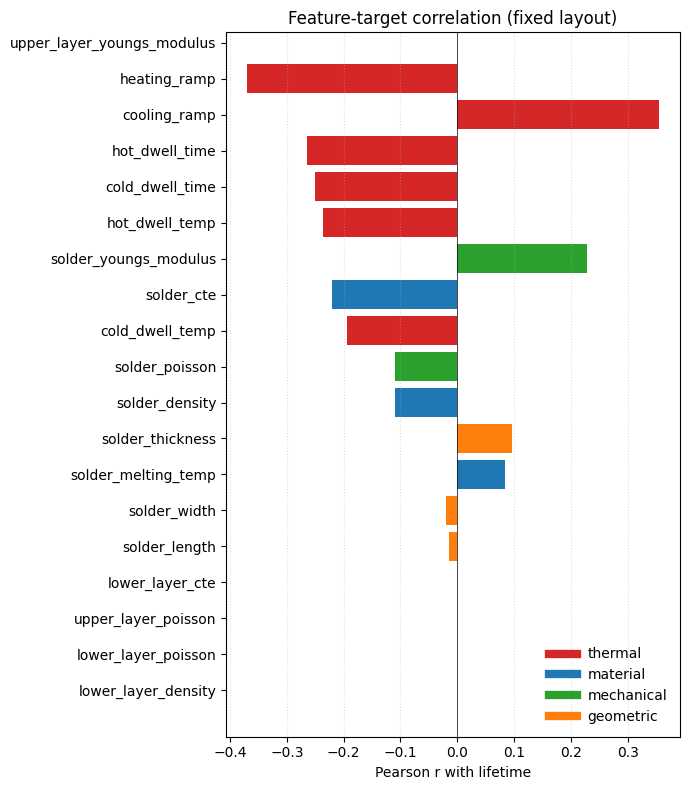

saved reports\figures\eda_feature_target_corr.png


In [8]:
target_corr = np.array([
    np.corrcoef(X_fixed[:, i], y_fixed)[0, 1] for i in range(24)
])
order = np.argsort(np.abs(target_corr))[::-1]

print('Features ranked by |corr| with target:')
for i in order:
    print(f'  {target_corr[i]:+.4f}  [{FEATURE_GROUP_OF[i]:10s}]  {FEATURE_NAMES[i]}')

fig, ax = plt.subplots(figsize=(7, 8))
labels = [FEATURE_NAMES[i] for i in order][::-1]
vals   = [target_corr[i]    for i in order][::-1]
colors = [GROUP_COLORS[FEATURE_GROUP_OF[i]] for i in order][::-1]
ax.barh(labels, vals, color=colors)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Pearson r with lifetime')
ax.set_title('Feature-target correlation (fixed layout)')
ax.grid(axis='x', linestyle=':', alpha=0.4)

handles = [plt.Line2D([0], [0], color=c, lw=6, label=g)
           for g, c in GROUP_COLORS.items()]
ax.legend(handles=handles, frameon=False, loc='lower right')
fig.tight_layout()
p = viz.save_figure(fig, 'eda_feature_target_corr')
plt.show()
print('saved', p)

## 6. Takeaways for the next notebooks

The layout proof is the headline. `X_fixed[0]` and `X_orig[0]` are visibly different pairings of feature values to a single sample's target. Every model trained on the original layout learned from mixed-sample rows.

The feature distributions and target distribution set the stage:

- **The target is wide.** Nothing trivial will predict it from a single feature. That is expected for a reliability problem.
- **The GAN has to learn a 25-dimensional joint distribution from 450 samples.** Small sample, wide distribution. The synthetic data will smooth the space, not replicate it exactly. That is documented in `data/README.md`.
- **Correlations here are univariate.** The models in notebooks 3 and 4 can still pick up multivariate structure the correlation column misses.

Next: `02_gan_synthesis.ipynb`, which trains the GAN on this data, plots the losses, and exports the 5,000 synthetic samples.
